In [1]:
from pathlib import Path
base = Path.cwd()
if "notebooks" in base.name:
    %cd ..
print(f"Running from path {Path.cwd()}")

/Users/peli/Projects/Repositories/DDM-NumEstPark
Running from path /Users/peli/Projects/Repositories/DDM-NumEstPark


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import dataframe_image as dfi
import joblib
import pymc as pm
import pytensor.tensor as at
import arviz as az
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import graphviz
import seaborn as sns
from datetime import datetime
from src.model import build_hierarchical_lnlik, build_null_lnlik
from src.utils import get_paths

In [4]:
# Setup
az.style.use("arviz-docgrid") # set arviz style
# setup main vars of interest
# set plot output dir
model_name = "comp"
plot_dir = Path("plots") / model_name
plot_dir.mkdir(exist_ok=True)
# save plot function

In [4]:
def get_sub_paths():
    """
    Return a list of all file paths of csv data
    """
    dir = "data"
    base = Path.cwd()
    data_dir = base / dir
    data_files = list(data_dir.glob('*.csv'))
    print(f"data_files {data_files}")
    return data_files

def get_subject_data():
    files = get_sub_paths()
    file = files[0]
    df = pd.read_csv(file)
    print(df.head(5))
    subject_df = df[df["S_ID"] == "S_00"]

    x_stim = subject_df["Presented_numerosity"]
    y_obs = subject_df["Estimated_numerosity"]

    print(f"Length n_stim {len(x_stim)}")
    print(f"n_stim: {x_stim.value_counts().sort_index()}")
    print(f"Length y_obs {len(y_obs)}")
    print(f"y_obs: {y_obs.value_counts().sort_index()}")
    return x_stim, y_obs

def get_all_data(
        subset_prop: float | None = None
):
    path = get_paths("dataset", "*")

    df = pd.read_csv(path)
    

    if subset_prop:
        assert 0 < subset_prop < 1
        np.random.seed(89)
        # Get unique subject IDs
        unique_subjects = df["S_ID"].unique()
        # Randomly sample ~20% of subjects
        n_subset = max(1, int(subset_prop * len(unique_subjects)))  # at least 1 subject
        sampled_subjects = np.random.choice(
            unique_subjects, 
            size=n_subset, 
            replace=False
        )
        # Filter dataframe to only those subjects
        df = df[df["S_ID"].isin(sampled_subjects)].reset_index(drop=True)

    X = df
    

    return X



In [5]:
# Load data
X = get_all_data()

# Encode hallucination group as Categorical (trial-level, but will extract per subject)
X["s_param_ph"] = X["s_param_ph"].replace({"1mh": "3mhch"})
order = ['0nh', '3mhch']
X["s_param_ph"] = pd.Categorical(X["s_param_ph"], categories=order, ordered=True)

# 1. Count UNIQUE subjects per hallucination group
subject_groups = X.drop_duplicates("S_ID")[["S_ID", "s_param_ph"]]
group_counts = subject_groups["s_param_ph"].value_counts().reindex(order, fill_value=0)
print("Number of subjects per hallucination group (s_param_ph):")
print(group_counts)
print()

# Number of unique participants
n_subjects_total = X["S_ID"].nunique()
print(f"Total number of unique subjects: {n_subjects_total}")

# Presented simtuli and estimated stimuli statistics
x_min = X["Presented_numerosity"].min()
x_max = X["Presented_numerosity"].max()
print(f"Presented numerosity Min: {x_min} Max: {x_max}")
y_min = X["Estimated_numerosity"].min()
y_max = X["Estimated_numerosity"].max()
y_mean = X["Estimated_numerosity"].mean()
print(f"Estimated numerosity Min: {y_min} Max: {y_max} Mean: {y_mean}")


data_files [PosixPath('/Users/peli/Projects/Repositories/DDM-NumEstPark/dataset/study2.csv')]
unpacked list
Number of subjects per hallucination group (s_param_ph):
s_param_ph
0nh      55
3mhch    63
Name: count, dtype: int64

Total number of unique subjects: 118
Presented numerosity Min: 5 Max: 8
Estimated numerosity Min: -11 Max: 112 Mean: 7.66207627118644


Remaining rows: 9361


(array([1.488e+03, 3.715e+03, 1.665e+03, 1.610e+03, 1.800e+02, 3.960e+02,
        8.400e+01, 1.600e+02, 6.000e+00, 3.400e+01, 1.000e+01, 5.000e+00,
        2.000e+00, 3.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00]),
 array([ 4.        ,  5.53333333,  7.06666667,  8.6       , 10.13333333,
        11.66666667, 13.2       , 14.73333333, 16.26666667, 17.8       ,
        19.33333333, 20.86666667, 22.4       , 23.93333333, 25.46666667,
        27.        , 28.53333333, 30.06666667, 31.6       , 33.13333333,
        34.66666667, 36.2       , 37.73333333, 39.26666667, 40.8       ,
        42.33333333, 43.86666667, 45.4       , 46.93333333, 48.46666667,
        50.        ]),
 <BarContainer object of 30 artists>)

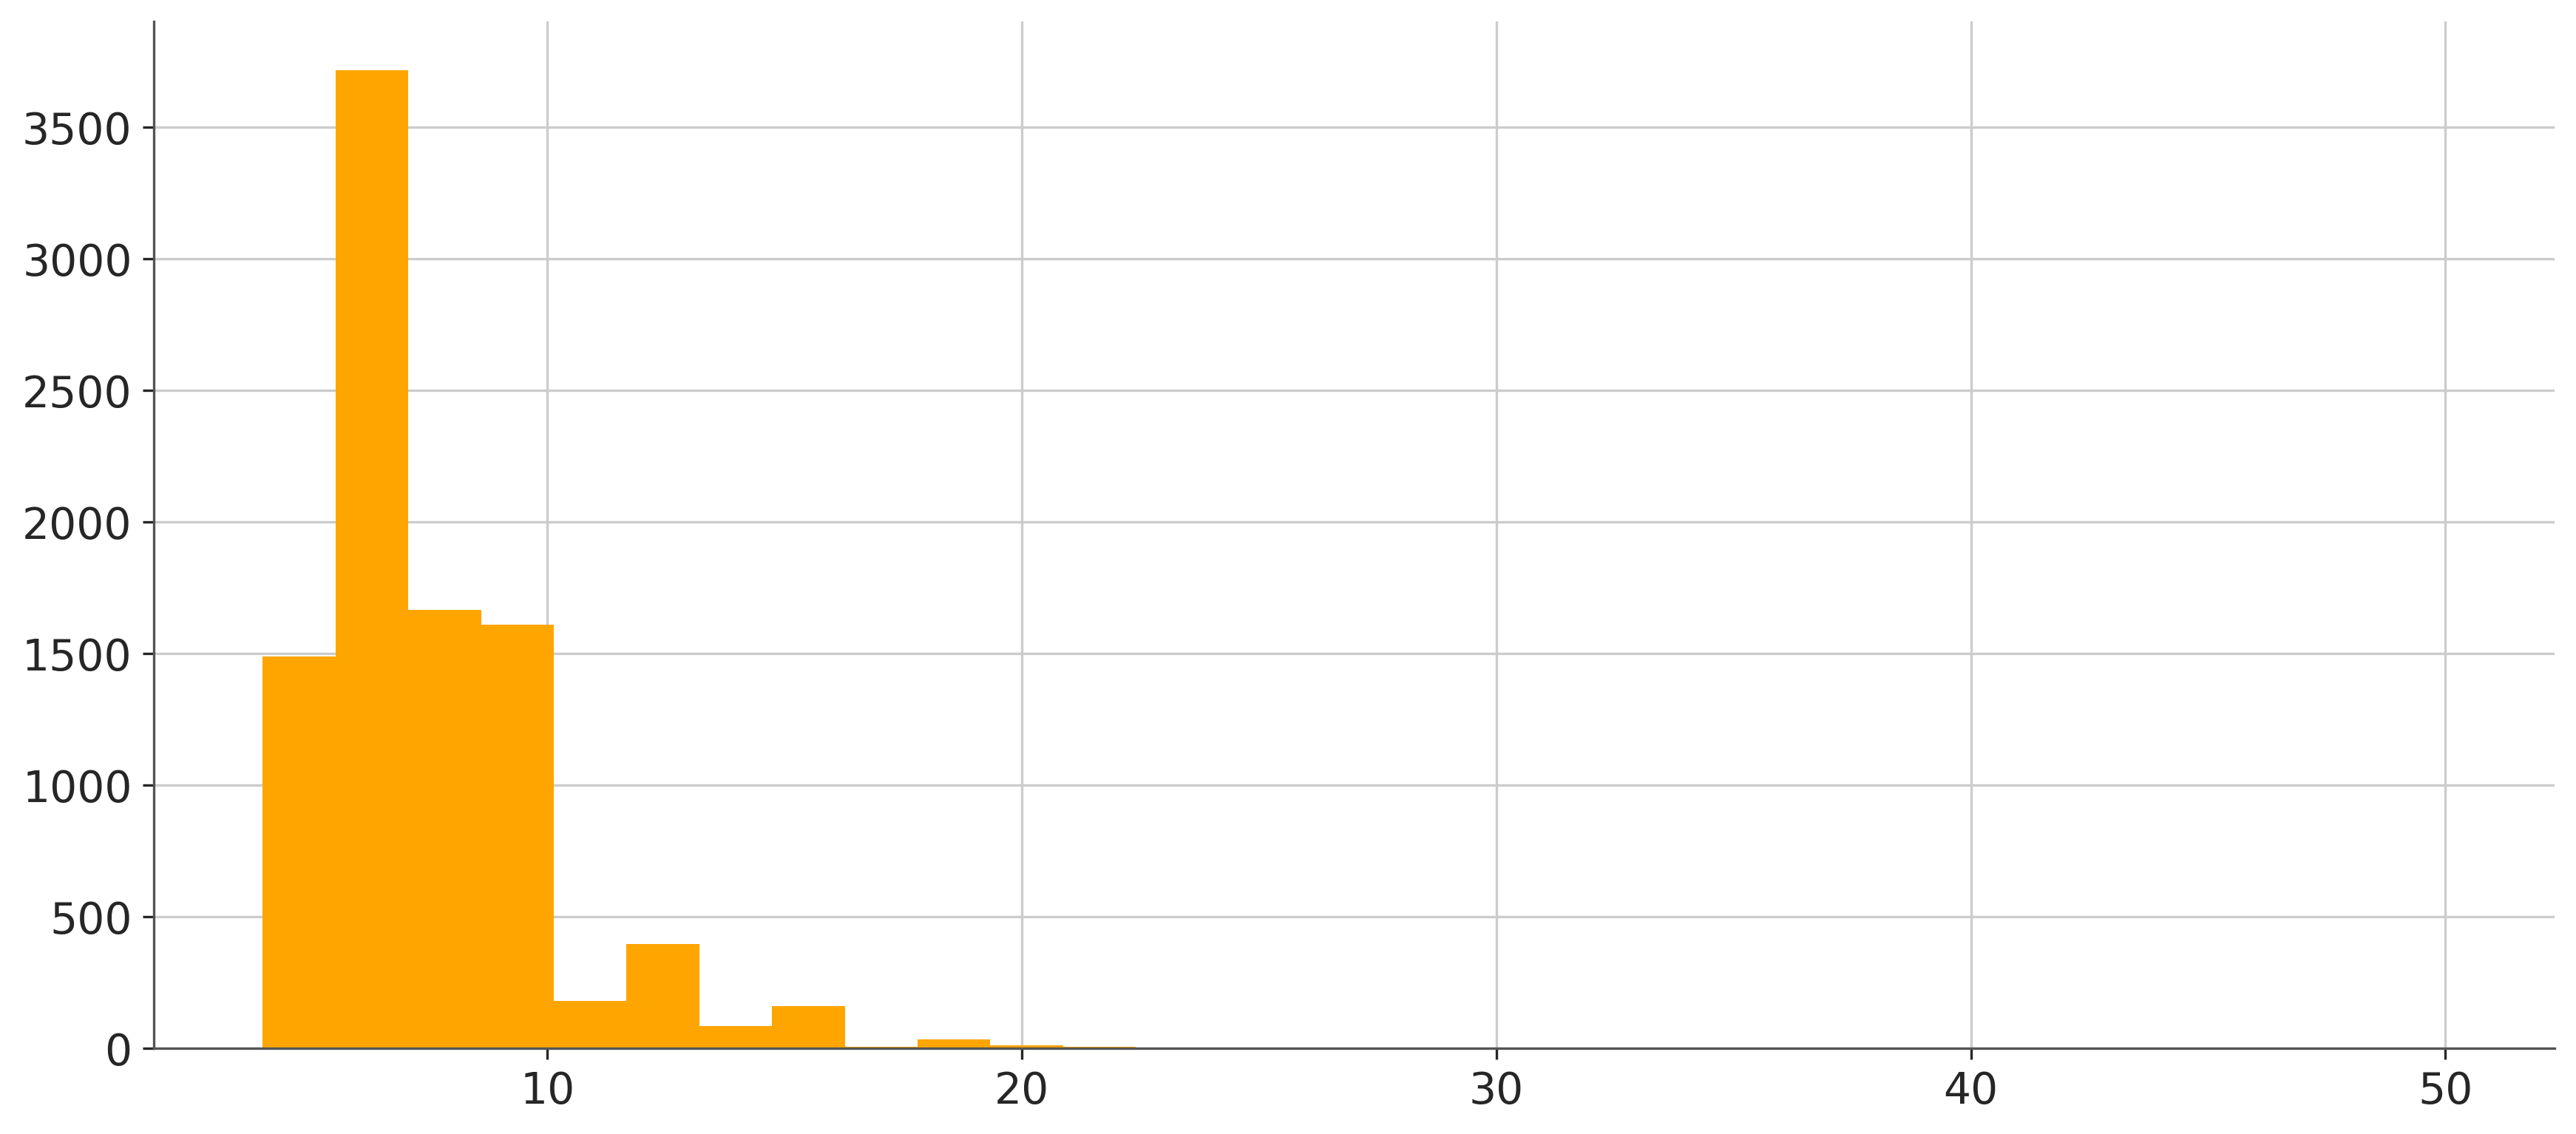

In [6]:
# remove rows where Estimated_numerosity > 24
X = X[X["Estimated_numerosity"].between(4, 50)].copy()

# optional: check result
print(f"Remaining rows: {len(X)}")
plt.hist(X["Estimated_numerosity"], bins=30, color="orange")

In [7]:

# Encode entity (trial-level)
entity, entity_labels = pd.factorize(X["entity"])  # shape (n_trials,)
print(entity)

# Extract trial-level numerosity
x_stim = X["Presented_numerosity"].values
y_obs = X["Estimated_numerosity"].values
dose = X["dose"].values

# --- Build subject-level mapping ---
subject_info = X.drop_duplicates("S_ID").sort_values("S_ID")

# Map original S_ID → 0-based integer index (for PyMC)
subject_id_map = {subj: idx for idx, subj in enumerate(subject_info["S_ID"])}
subject_id = X["S_ID"].map(subject_id_map).values.astype(int)  # shape (n_trials,) → ✅ REPEATS ARE OK

# ✅ CORRECT: extract integer group codes at SUBJECT level
ph_type = subject_info["s_param_ph"].cat.codes.values  # shape (n_subjects,), dtype=int

# Optional: sanity checks
assert len(ph_type) == len(subject_info), "Group codes must be per subject"
assert subject_id.max() == len(ph_type) - 1, "subject_id must align with group codes"
assert set(np.unique(ph_type)) <= {0, 1, 2}, "Invalid group codes"

print(f"subject_id {len(subject_id)}")
print(f"ph_type {len(ph_type)}")

[0 0 0 ... 1 1 1]
subject_id 9361
ph_type 118


In [8]:
print(f"Building model ...")
model_null = build_null_lnlik(
    x_stim,
    y_obs,
    subject_id,
    ph_type,
    entity
)
model_hir = build_hierarchical_lnlik(
    x_stim,
    y_obs,
    subject_id,
    ph_type,
    entity
)

sample_config = {
    "draws": 4000,
    "tune": 2000,
    "target_accept": 0.9,
    "chains": 4,
    "random_seed": 94,
    "idata_kwargs": {"log_likelihood": True}
}


Building model ...


Sampling: [beta, log_alpha, sigma, y]


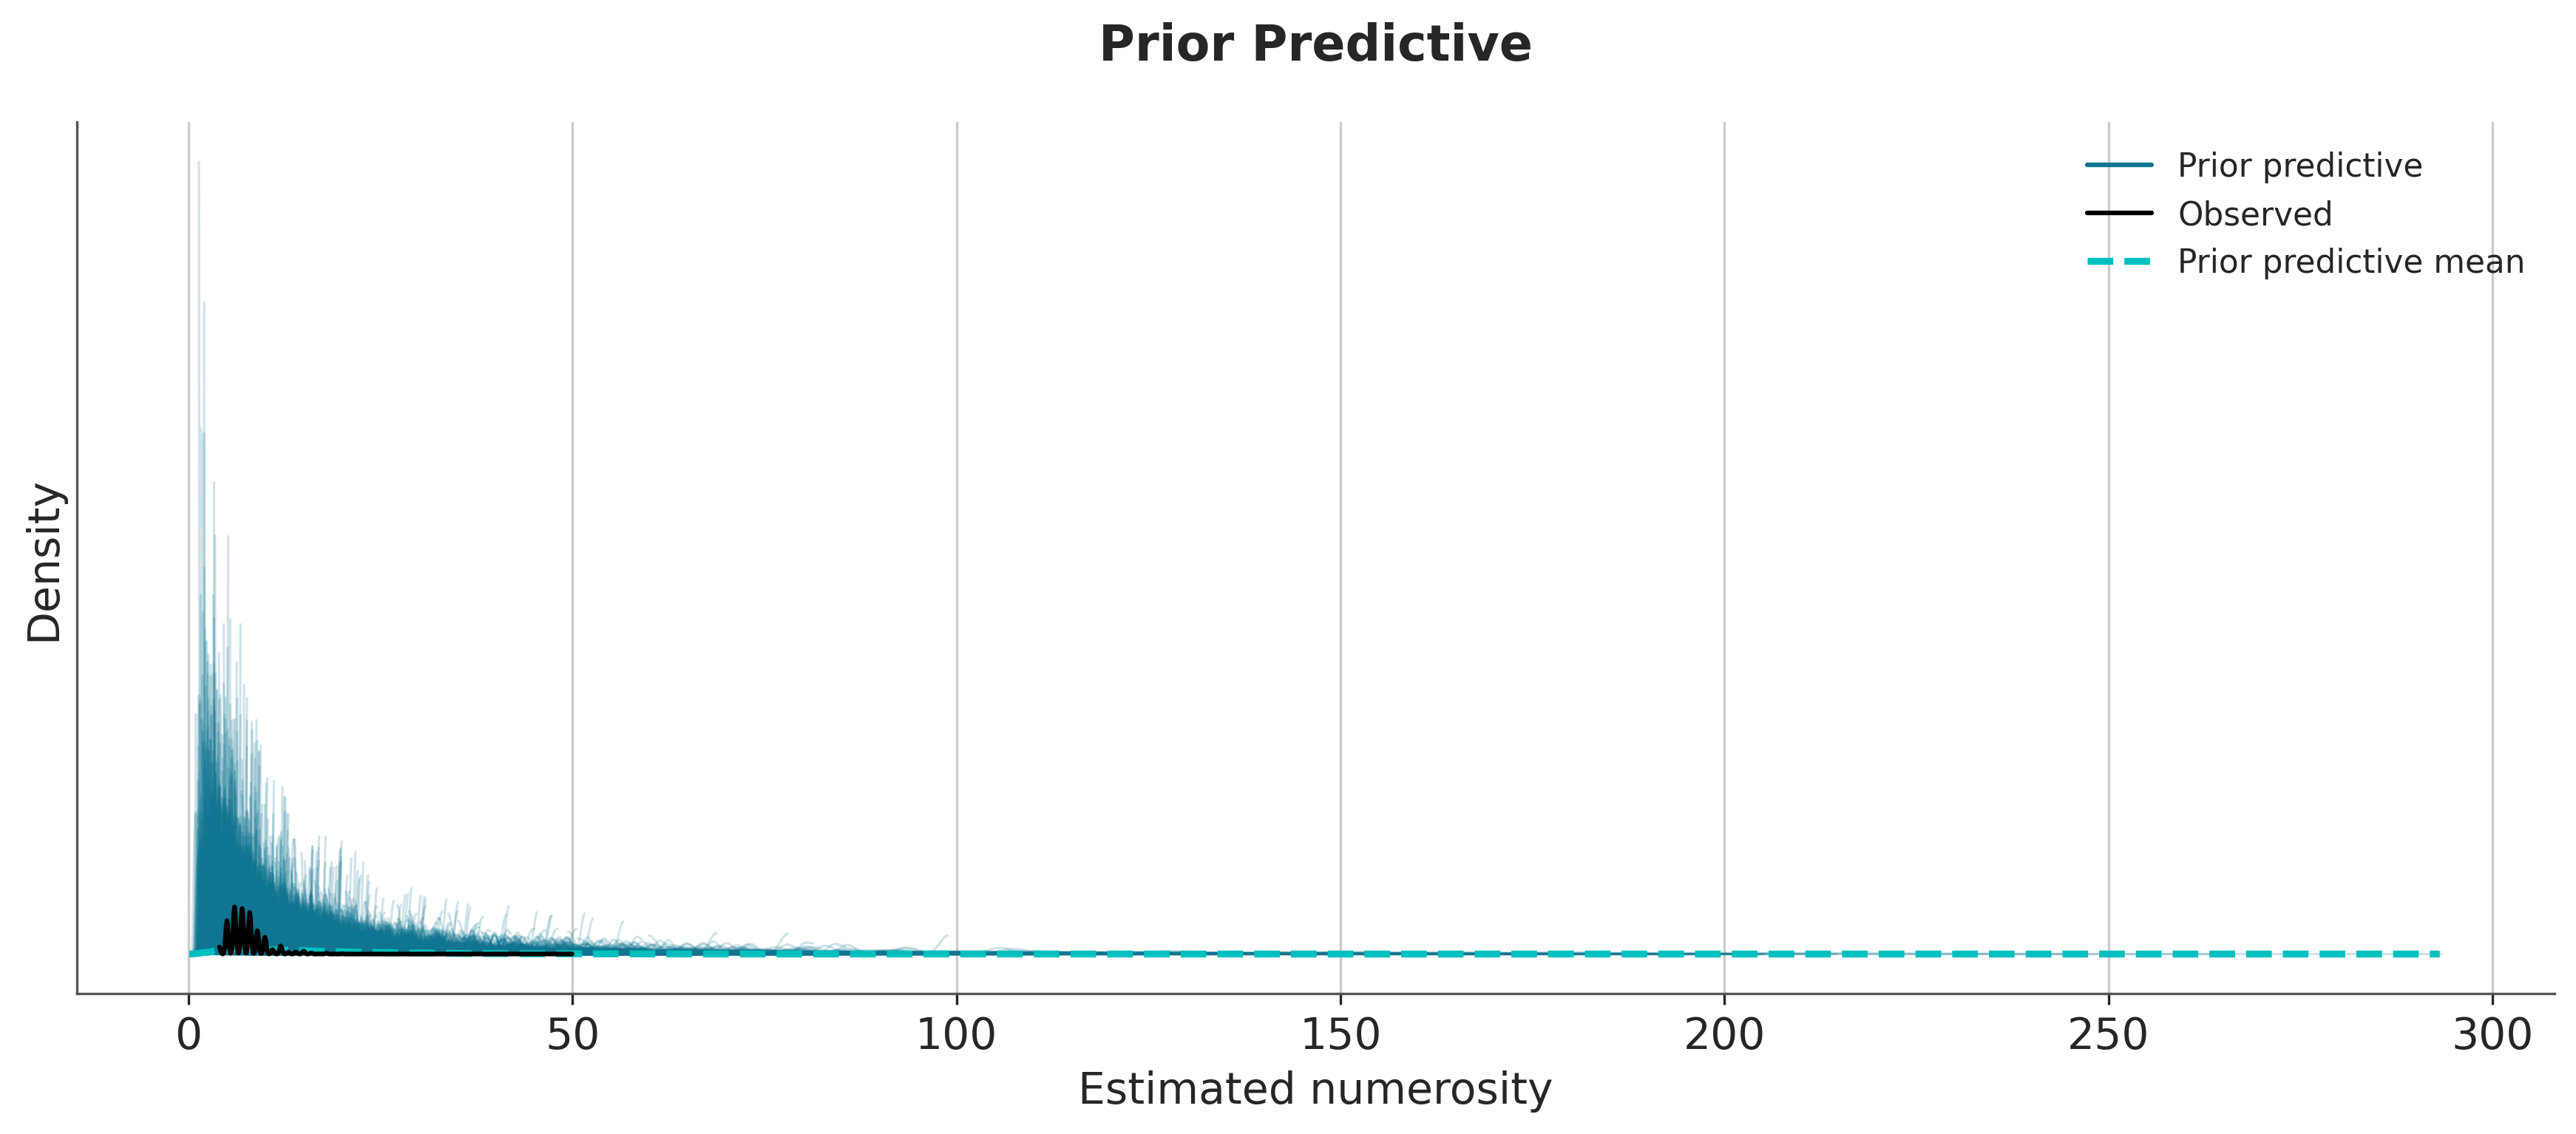

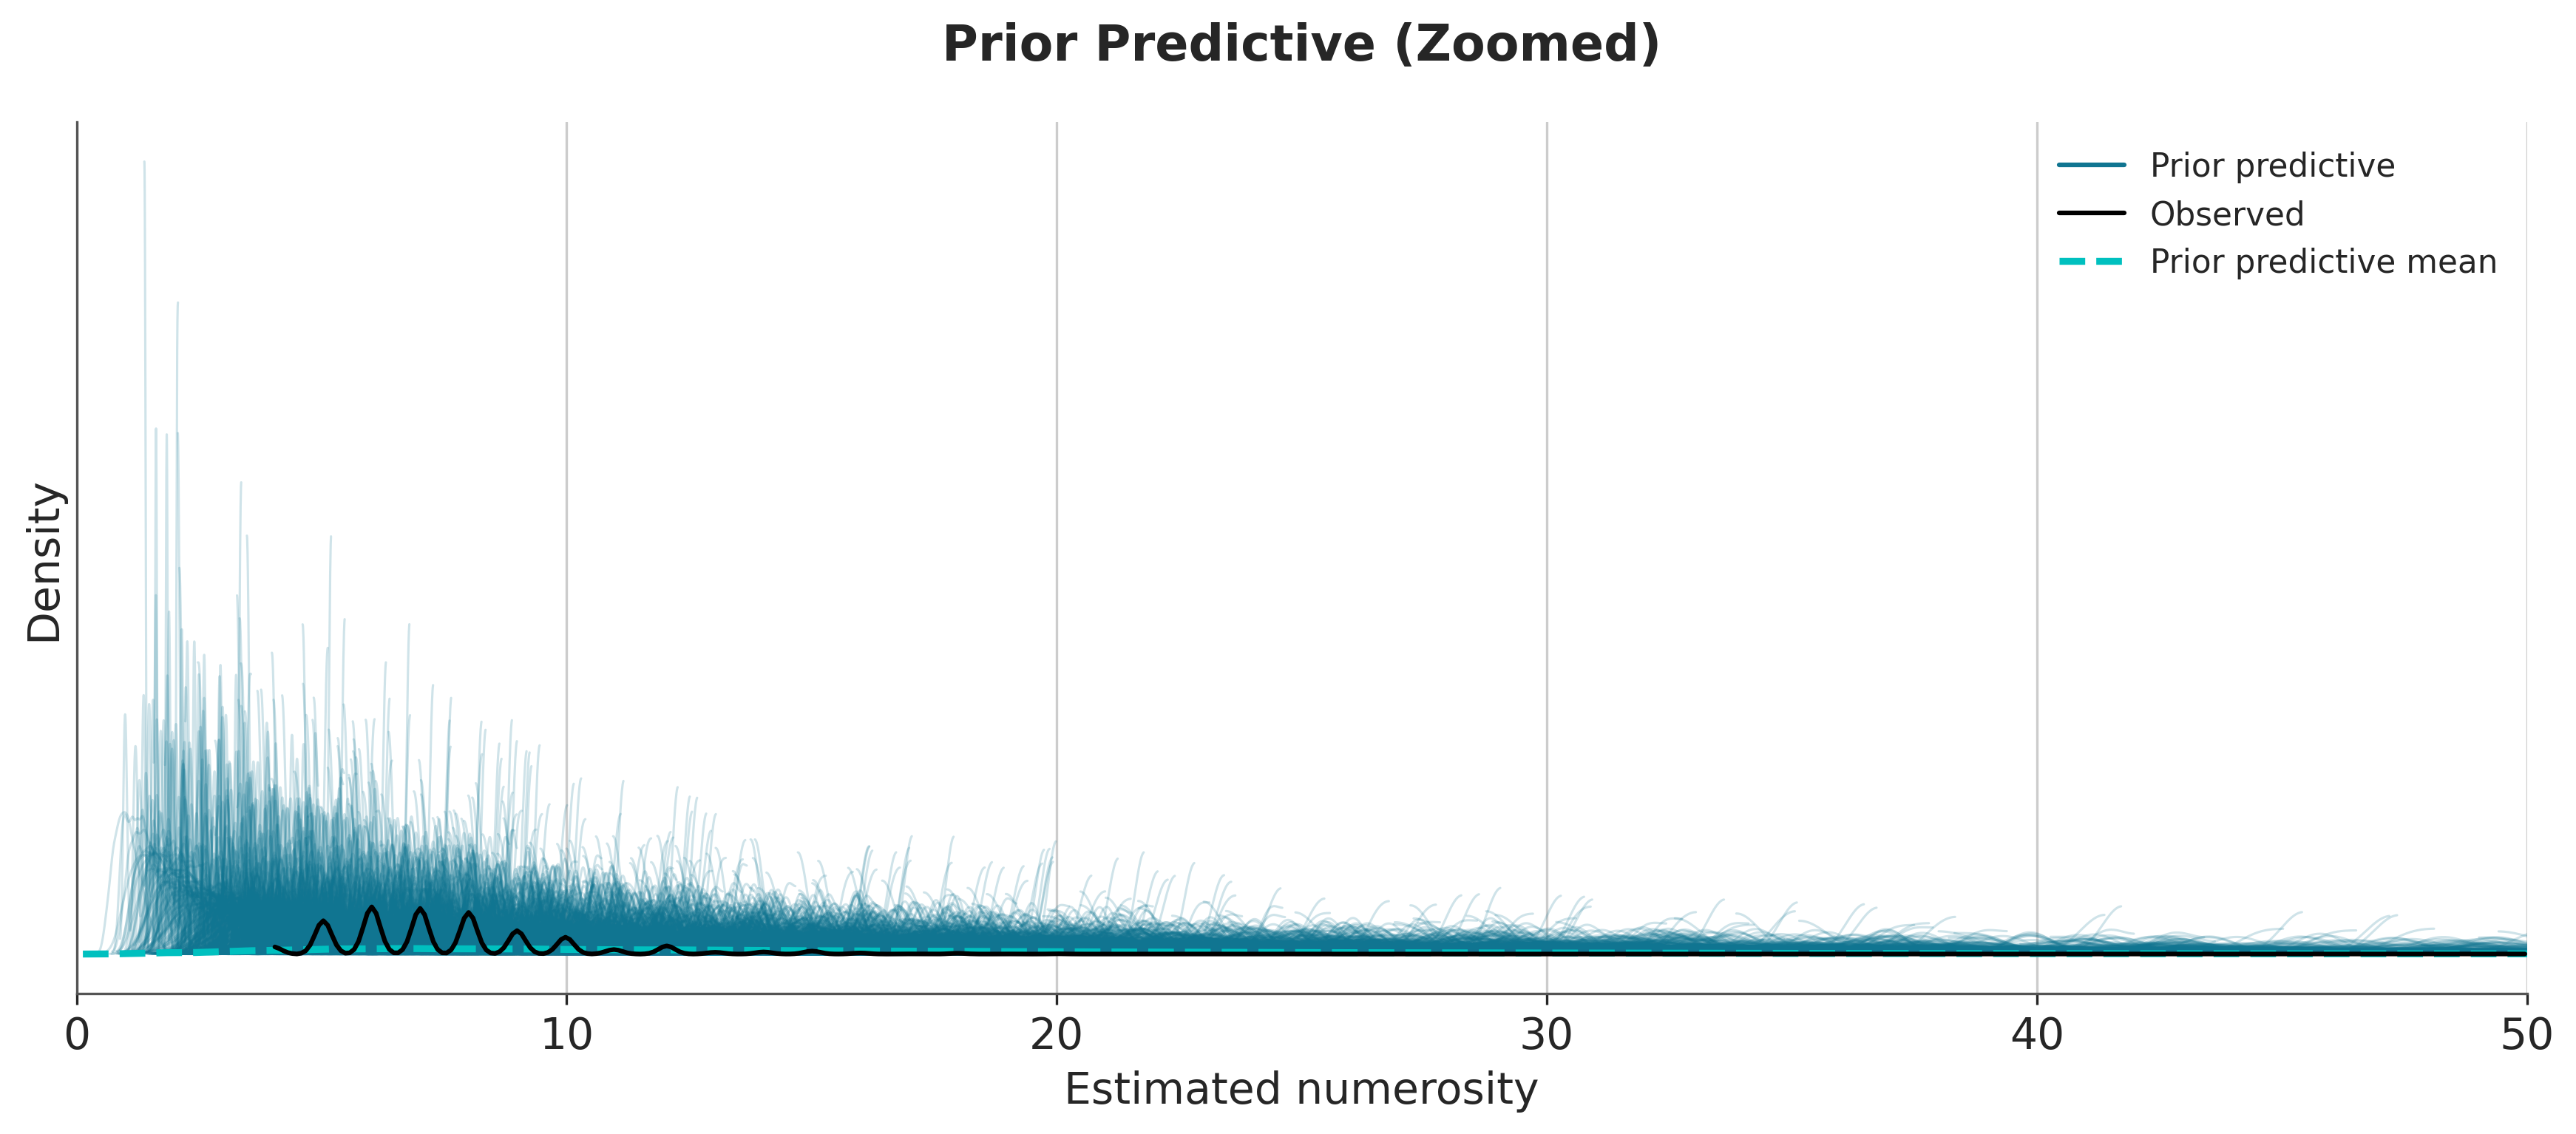

In [9]:
# sanity prior-predictive check
with model_null:
    prior_pred = pm.sample_prior_predictive(
        samples=5000,
        var_names=["y","y_pred"],
        random_seed=23
    )

    
axes = az.plot_ppc(prior_pred, group="prior", observed="y")
axes.set_title("Prior Predictive", y=1.05)
axes.set_xlabel("Estimated numerosity")
axes.set_ylabel("Density")
fig = axes.figure
fig.savefig(plot_dir/"prior_pred_full.png")

axes_zoom = az.plot_ppc(prior_pred, group="prior", observed="y")
axes_zoom.set_xlim([0,50])
axes_zoom.set_title("Prior Predictive (Zoomed)", y=1.05)
axes_zoom.set_xlabel("Estimated numerosity")
axes_zoom.set_ylabel("Density")

# Save figure
fig = axes_zoom.figure  # get figure from axes

In [10]:
# Sampling
models = [model_null, model_hir]
posteriors = []
for model in models:
    with model:

        trace = pm.sample(**sample_config)

        post_pred = pm.sample_posterior_predictive(
            trace, 
            var_names=["y", "y_pred"],
            random_seed=423
        )

        trace.extend(post_pred)
        idata = trace
        posteriors.append(idata)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_alpha, beta, sigma]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 18 seconds.
Sampling: [y]


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_alpha_mu, log_alpha_sigma, log_alpha_subj, beta_mu, beta_sigma, beta_subj, sigma_group]


Output()

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 521 seconds.
Sampling: [y]


Output()

# Compute LOO model comparison

In [14]:
# compute loo model comparison
null_loo = az.loo(posteriors[0])
hir_loo = az.loo(posteriors[1])

# compare loos
df_comp_loo = az.compare({"hierarchical": hir_loo, "null": null_loo})

/Users/peli/Projects/Repositories/DDM-NumEstPark/.venv/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning:

Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.



In [ ]:
df.to_html("plots/comp/loo_tab.html")

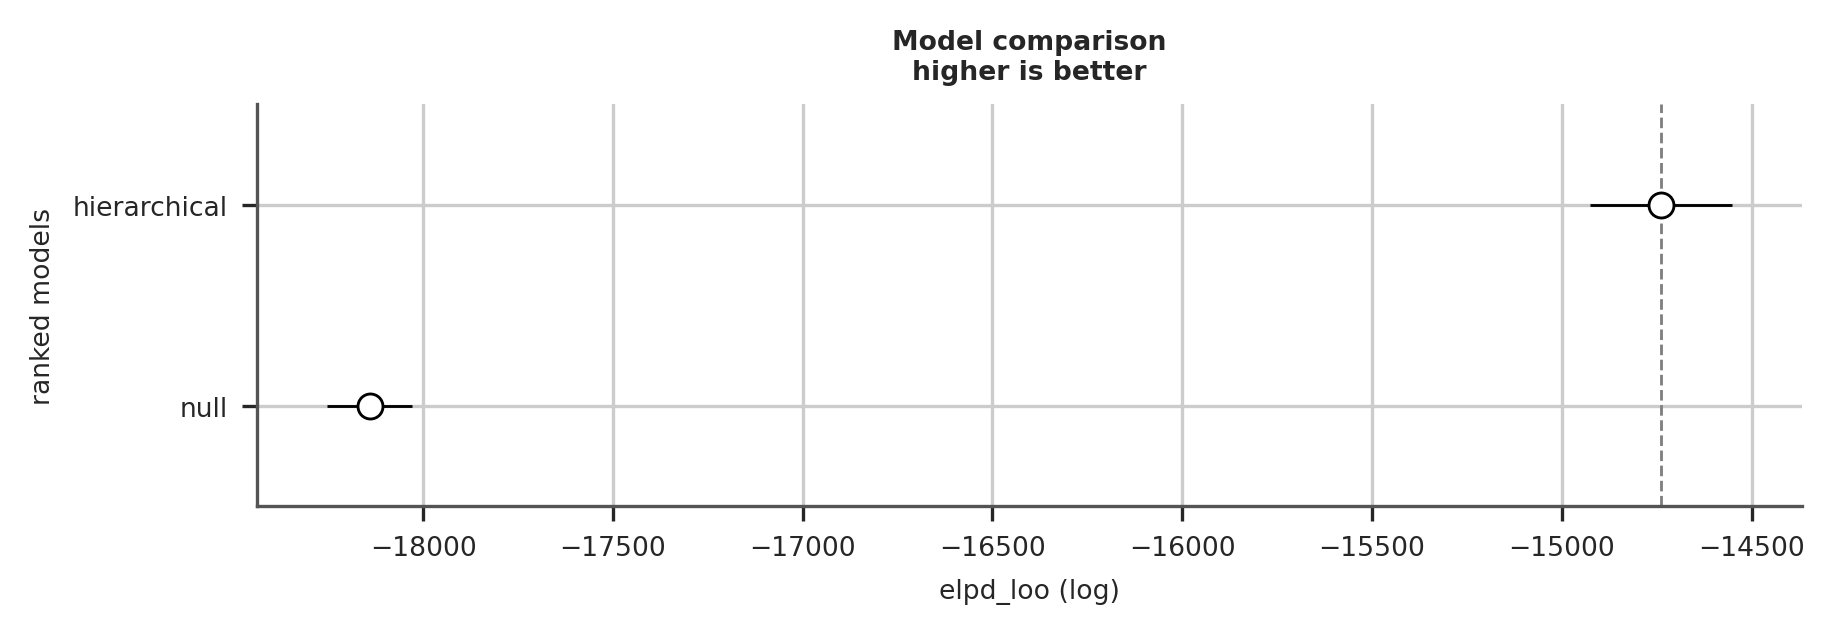

In [17]:
# plot comparison
fig = az.plot_compare(df_comp_loo, insample_dev=False);

outdir = Path("plots") / "comp"
outdir.mkdir(exist_ok=True)
plt.savefig(outdir/"loo.png")